In [ ]:
pip install mtcnn tensorflow pillow imgaug

In [ ]:
!pip install "numpy<2.0"

In [ ]:
# Import necessary libraries
from PIL import Image
import numpy as np
from mtcnn.mtcnn import MTCNN
import os
import imgaug.augmenters as iaa
import matplotlib.pyplot as plt

In [23]:
def process_and_save_partitions(image_path, output_folder="processed_data"):
    """
    Main function to detect, partition, resize, and augment a face from an image.
    """
    # --- Setup ---
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
        os.makedirs(os.path.join(output_folder, "resized"))
        os.makedirs(os.path.join(output_folder, "augmented"))

    try:
        image = Image.open(image_path).convert('RGB')
    except FileNotFoundError:
        print(f"Error: Image not found at {image_path}")
        return

    image_np = np.asarray(image)
    detector = MTCNN()
    faces = detector.detect_faces(image_np)

    if not faces:
        print("No face detected.")
        return

    # --- Detection and Cropping ---
    face_data = faces[0]
    x, y, width, height = face_data['box']
    landmarks = face_data['keypoints']
    cropped_face = image.crop((x, y, x + width, y + height))

    # --- Landmark-Based Partitioning ---
    left_eye_rel = (landmarks['left_eye'][0] - x, landmarks['left_eye'][1] - y)
    right_eye_rel = (landmarks['right_eye'][0] - x, landmarks['right_eye'][1] - y)
    mouth_left_rel = (landmarks['mouth_left'][0] - x, landmarks['mouth_left'][1] - y)
    mouth_right_rel = (landmarks['mouth_right'][0] - x, landmarks['mouth_right'][1] - y)

    eye_level_y = (left_eye_rel[1] + right_eye_rel[1]) / 2
    mouth_level_y = (mouth_left_rel[1] + mouth_right_rel[1]) / 2
    
    cut_line_1 = int(eye_level_y + height * 0.10)
    cut_line_2 = int(mouth_level_y - height * 0.10)

    cut_line_1 = max(0, min(cut_line_1, height))
    cut_line_2 = max(0, min(cut_line_2, height))

    if cut_line_1 >= cut_line_2:
        cut_line_1, cut_line_2 = int(height * 0.40), int(height * 0.65)

    face_width = cropped_face.width
    partitions = {
        "top": cropped_face.crop((0, 0, face_width, cut_line_1)),
        "mid": cropped_face.crop((0, cut_line_1, face_width, cut_line_2)),
        "bottom": cropped_face.crop((0, cut_line_2, face_width, height))
    }

    print("Partitions created successfully.")

    # --- Define Target Sizes for Each Partition ---
    # These sizes are what your models will expect as input.
    target_sizes = {
        "top": (112, 64),  # Width x Height
        "mid": (112, 56),
        "bottom": (112, 64)
    }

    # --- Process Each Partition ---
    base_filename = os.path.splitext(os.path.basename(image_path))[0]
    resized_partitions = {}
    
    for name, part_image in partitions.items():
        # --- 1. Resizing ---
        target_size = target_sizes[name]
        # Using LANCZOS for high-quality downsampling
        resized_image = part_image.resize(target_size, Image.Resampling.LANCZOS)
        resized_partitions[name] = resized_image # Store for visualization
        
        # Save the resized image
        resized_image.save(os.path.join(output_folder, "resized", f"{base_filename}_{name}_resized.jpg"))
        
        # --- 2. Simple Augmentation (Horizontal Flip) ---
        # Augment the RESIZED image
        augmented_image = augment_image(resized_image)
        augmented_image.save(os.path.join(output_folder, "augmented", f"{base_filename}_{name}_augmented_flip.jpg"))

    print(f"\nSaved resized and augmented partitions to the '{output_folder}' folder.")
    
    # --- Visualization (Great for Jupyter!) ---
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.suptitle('Original, Resized, and Augmented (Flipped) Partitions', fontsize=16)

    # Plotting Top Partition
    axes[0, 0].set_title("Original Top")
    axes[0, 0].imshow(partitions['top'])
    axes[0, 1].set_title(f"Resized Top\n{target_sizes['top'][0]}x{target_sizes['top'][1]}")
    axes[0, 1].imshow(resized_partitions['top'])
    axes[0, 2].set_title("Augmented (Flipped)")
    axes[0, 2].imshow(Image.open(os.path.join(output_folder, "augmented", f"{base_filename}_top_augmented_flip.jpg")))

    # Plotting Mid Partition
    axes[1, 0].set_title("Original Mid")
    axes[1, 0].imshow(partitions['mid'])
    axes[1, 1].set_title(f"Resized Mid\n{target_sizes['mid'][0]}x{target_sizes['mid'][1]}")
    axes[1, 1].imshow(resized_partitions['mid'])
    axes[1, 2].set_title("Augmented (Flipped)")
    axes[1, 2].imshow(Image.open(os.path.join(output_folder, "augmented", f"{base_filename}_mid_augmented_flip.jpg")))

    # Plotting Bottom Partition
    axes[2, 0].set_title("Original Bottom")
    axes[2, 0].imshow(partitions['bottom'])
    axes[2, 1].set_title(f"Resized Bottom\n{target_sizes['bottom'][0]}x{target_sizes['bottom'][1]}")
    axes[2, 1].imshow(resized_partitions['bottom'])
    axes[2, 2].set_title("Augmented (Flipped)")
    axes[2, 2].imshow(Image.open(os.path.join(output_folder, "augmented", f"{base_filename}_bottom_augmented_flip.jpg")))

    for ax_row in axes:
        for ax in ax_row:
            ax.axis('off')
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

In [22]:
def normalize_image(image_pil):
    """
    Normalizes a PIL image by converting it to a NumPy array,
    scaling pixel values to the [0, 1] range, and returning it.
    """
    image_np = np.asarray(image_pil).astype(np.float32)
    # Scale pixel values from [0, 255] to [0, 1]
    normalized_np = image_np / 255.0
    return normalized_np

def augment_image(image_pil):
    """
    Applies a simple horizontal flip augmentation.
    """
    # Convert PIL image to NumPy array for imgaug
    image_np = np.asarray(image_pil)
    
    # Define a simple augmentation sequence: just a horizontal flip
    seq = iaa.Sequential([
        iaa.Fliplr(1.0), # always flip horizontally for this example
    ])

    # Augment the image
    augmented_np = seq(image=image_np)
    
    # Convert back to PIL Image
    augmented_pil = Image.fromarray(augmented_np)
    
    return augmented_pil

In [20]:
from PIL import Image

input_image_path = "test_image.jpg"
image = Image.open(input_image_path)

# Display the image (optional)
image.show()


Partitions created successfully.

Saved resized and augmented partitions to the 'processed_data' folder.


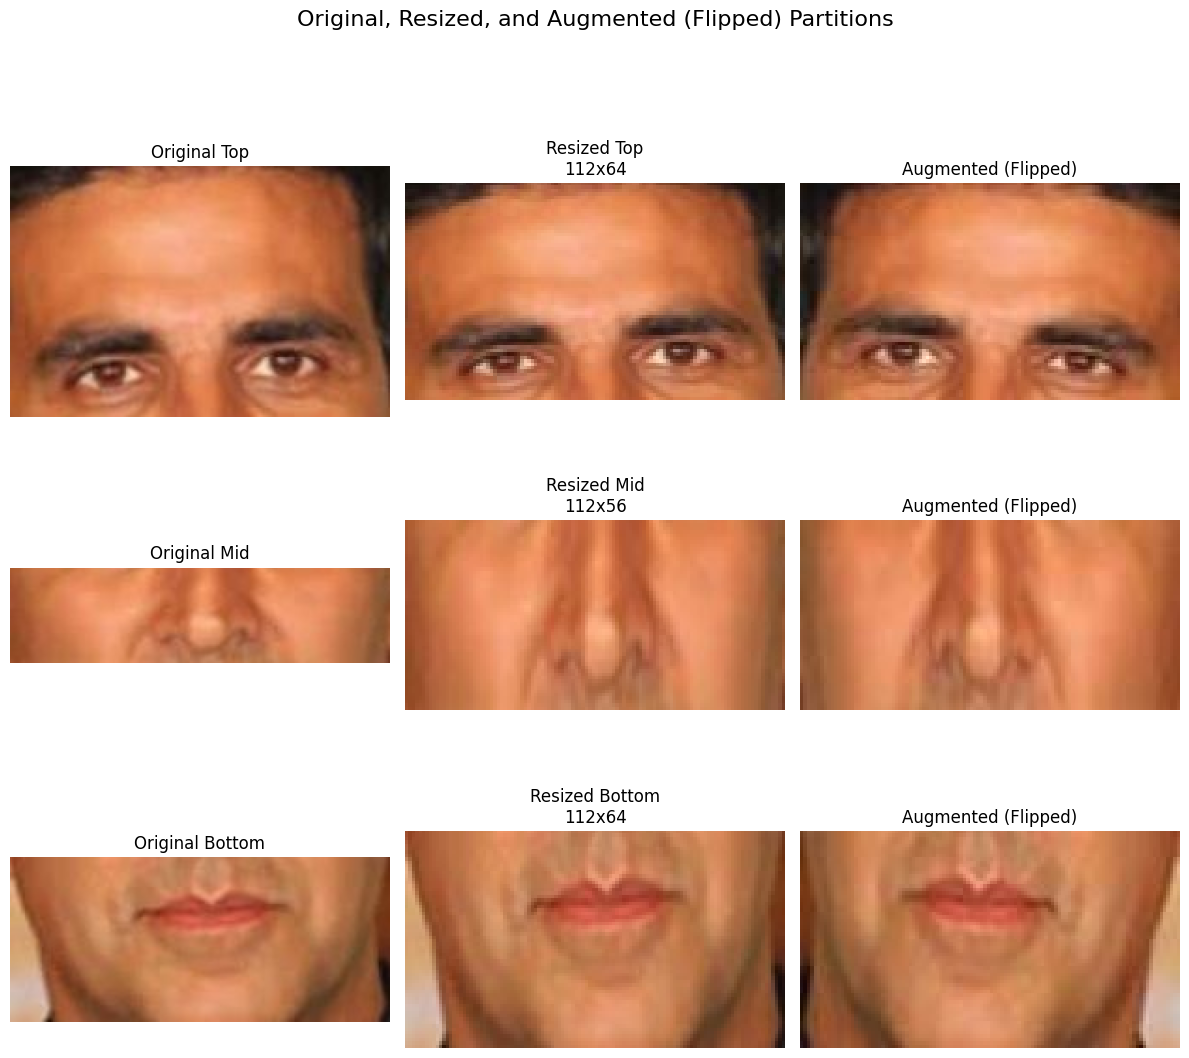

In [24]:
process_and_save_partitions(input_image_path)

In [ ]:
// --- Initialization ---
1:  Define input_video_folder, output_image_folder, output_partitions_folder
2:  Define partition_ratios = {top: 0.35, mid: 0.30, bottom: 0.35}
3:  Initialize face_detector (e.g., MTCNN)
4:  Create empty list: dataset_manifest = []

5:  // --- Main Loop: Process each video file ---
6:  for each video_file in input_video_folder:
7:      Let person_label = get_label_from_filename_or_folder(video_file)
8:      Let video_capture = open_video(video_file)
9:      Let frame_count = 0
10:     // --- 4.4.2.1. Frame-by-Frame Extraction ---
11:     while video_capture has frames:
12:         Let raw_frame = read_next_frame(video_capture)
13:         if raw_frame is null, break loop
14: 
15:         // --- 4.4.2.2. Labeling (Implicitly handled by folder structure) ---
16:         // Raw frames are associated with person_label
17: 
18:         // --- 4.4.2.3. Grayscale ---
19:         Let gray_frame = convert_to_grayscale(raw_frame)
20: 
21:         // --- 4.4.2.4. Face Detection ---
22:         Let detected_faces = face_detector.detect(gray_frame)
23: 
24:         // Process only if one clear face is found
25:         if count(detected_faces) == 1:
26:             Let face_data = detected_faces[0]
27:             Let bounding_box = face_data.bounding_box
28:             Let landmarks = face_data.landmarks
29: 
30:             // --- 4.4.2.5. Face Alignment & Cropping (of whole face) ---
31:             Let aligned_whole_face = align_and_crop(raw_frame, bounding_box, landmarks)
32: 
33:             if aligned_whole_face is not null:
34:                 // --- 4.4.2.6. Face Partitioning ---
35:                 Let face_height = get_height(aligned_whole_face)
36:                 Let top_end = face_height * partition_ratios.top
37:                 Let mid_end = top_end + (face_height * partition_ratios.mid)
38: 
39:                 Let partition_top = crop_image(aligned_whole_face, y_start=0, y_end=top_end)
40:                 Let partition_mid = crop_image(aligned_whole_face, y_start=top_end, y_end=mid_end)
41:                 Let partition_bottom = crop_image(aligned_whole_face, y_start=mid_end, y_end=face_height)
42: 
43:                 Let partitions = {top: partition_top, mid: partition_mid, bottom: partition_bottom}
44: 
45:                 // --- 4.4.2.7. Image Augmentation & 4.4.2.8. Image Normalization ---
46:                 for each partition_name, partition_image in partitions:
47:                     // Augmentation is typically done during training, but for preprocessing
48:                     // we can save the base partitions. Here we just normalize and save.
49: 
50:                     // --- Image Normalization ---
51:                     Let normalized_partition = normalize_pixels(partition_image)
52: 
53:                     // --- Save the processed partition and update manifest ---
54:                     Let output_path = create_path(output_partitions_folder, person_label, partition_name, frame_count)
55:                     save_image(normalized_partition, output_path)
56:                     
57:                     // Add entry to our manifest CSV
58:                     Add row to dataset_manifest: {
59:                         original_video: video_file,
60:                         frame: frame_count,
61:                         label: person_label,
62:                         partition_type: partition_name,
63:                         file_path: output_path
64:                     }
65:                 end for
66:             end if
67:         end if
68:         frame_count = frame_count + 1
69:     end while
70: end for
71:
72: // --- Final Step: Save the manifest file ---
73: save_as_csv(dataset_manifest, "Dataset.csv")
74:
75: // Note: Dataset Balancing and Augmentation are often applied dynamically during training
76: // using a data loader, rather than creating augmented files on disk. The manifest
77: // file created here is the input to that data loader.